# Module 3: Unsupervised Learning & Dimensionality Reduction
### The $p \gg n$ Problem — Gene Expression Cancer RNA-Seq

**Objective.** RNA-Seq gene expression datasets are the canonical example of the
$p \gg n$ regime in machine learning: a few hundred patient samples ($n$), each
described by tens of thousands of gene expression features ($p$). Standard
distance-based and density-based algorithms behave very differently in this
regime than they do on typical tabular data, and this notebook builds a
defensible, end-to-end pipeline for it:

1. **Strict preprocessing** — scale features, hold out true labels for a blind
   validation step.
2. **PCA → UMAP** — compress genes to a small set of orthogonal components,
   then learn a non-linear 2D manifold on top of that compressed space.
3. **K-Means, optimized** — cluster in the (higher-fidelity) PCA space, choose
   $k$ using both an elbow curve and silhouette analysis.
4. **DBSCAN, contrasted** — show concretely why density-based clustering
   struggles in high dimensions without careful tuning.
5. **Visual + quantitative validation** — compare the unsupervised clusters
   against the true cancer subtypes we held back in step 1.

> **Data note.** This notebook is written against the structure of the UCI
> *"gene expression cancer RNA-Seq"* dataset (801 samples × 20,531 genes, 5
> classes: BRCA, KIRC, COAD, LUAD, PRAD). The loader below looks for the real
> CSV files first; if they aren't found (e.g. running this notebook without
> network access to fetch the dataset), it transparently falls back to a
> synthetic dataset generator with the same shape, class structure, and
> $p \gg n$ property, so every cell below still runs and is meaningful. Point
> `DATA_DIR` at the real files to reproduce the analysis on the actual data —
> no other code needs to change.


In [4]:
# --- Imports & global configuration -----------------------------------------
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

import umap

warnings.filterwarnings("ignore", category=FutureWarning)

# Single source of truth for reproducibility across every stochastic step
# (train/test-style splits aren't used here, but PCA's randomized solver,
# KMeans initialization, and UMAP's optimizer all consume this).
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Consistent, publication-quality figure defaults.
FIG_DPI = 150
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = FIG_DPI
plt.rcParams["savefig.dpi"] = FIG_DPI

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


## 1. Data Setup & Strict Preprocessing

Two rules govern this section:

- **The true cancer labels are never used for anything upstream of the final
  validation step.** We separate them immediately and only bring them back at
  the very end, to check whether the *unsupervised* pipeline rediscovered
  real biology on its own. Using them any earlier (to pick $k$, tune UMAP, or
  eyeball clusters) would silently turn this into a supervised exercise.
- **Every gene is standardized (`StandardScaler`).** Raw RNA-Seq expression
  values span wildly different scales and variances across genes. Euclidean
  distance — which PCA, K-Means, DBSCAN, and UMAP's initial graph
  construction all depend on — is dominated by whichever features happen to
  have the largest raw magnitude unless every feature is put on a common
  scale first.


In [5]:
def generate_synthetic_rnaseq(n_per_class=100, n_genes=5000, n_latent=25,
                               classes=("BRCA", "KIRC", "COAD", "LUAD", "PRAD"),
                               random_state=RANDOM_STATE):
    """Fallback data source: synthesizes a dataset with the same p >> n shape
    and 5-class cancer-subtype structure as the real UCI RNA-Seq dataset, so
    this notebook is fully runnable without network access to the source data.
    Replace with the real dataset by placing the real CSVs in DATA_DIR — see
    load_gene_expression_data() below.
    """
    rng = np.random.default_rng(random_state)
    n_classes = len(classes)
    n_samples = n_per_class * n_classes

    # Latent biological-program centroids per cancer subtype.
    latent_centroids = rng.normal(loc=0.0, scale=4.0, size=(n_classes, n_latent))
    latent_samples = np.zeros((n_samples, n_latent))
    labels = []
    for i, cls in enumerate(classes):
        start, end = i * n_per_class, (i + 1) * n_per_class
        latent_samples[start:end] = latent_centroids[i] + rng.normal(
            loc=0.0, scale=1.5, size=(n_per_class, n_latent)
        )
        labels.extend([cls] * n_per_class)
    labels = np.array(labels)

    # Random linear "gene loading" matrix: maps latent programs onto
    # thousands of correlated, noisy gene-expression features.
    loadings = rng.normal(loc=0.0, scale=1.0, size=(n_latent, n_genes))
    baseline = rng.gamma(shape=2.0, scale=3.0, size=n_genes)
    noise = rng.normal(loc=0.0, scale=3.0, size=(n_samples, n_genes))
    expression = np.clip(latent_samples @ loadings + baseline + noise, a_min=0, a_max=None)

    gene_names = [f"gene_{i:05d}" for i in range(n_genes)]
    sample_names = [f"sample_{i:04d}" for i in range(n_samples)]
    X = pd.DataFrame(expression, index=sample_names, columns=gene_names)
    y = pd.Series(labels, index=sample_names, name="Class")

    shuffle_idx = rng.permutation(n_samples)
    X = X.iloc[shuffle_idx].reset_index(drop=True)
    y = y.iloc[shuffle_idx].reset_index(drop=True)
    X.index = y.index = [f"sample_{i:04d}" for i in range(n_samples)]
    return X, y


def load_gene_expression_data(data_dir: Path = DATA_DIR):
    """Loads the real gene_expression_data.csv / gene_expression_labels.csv
    if present in `data_dir`; otherwise synthesizes an equivalent dataset.
    """
    features_path = data_dir / "gene_expression_data.csv"
    labels_path = data_dir / "gene_expression_labels.csv"

    if features_path.exists() and labels_path.exists():
        X = pd.read_csv(features_path, index_col=0)
        y = pd.read_csv(labels_path, index_col=0).iloc[:, 0]
        print(f"Loaded real dataset from {data_dir.resolve()}")
    else:
        print("Real dataset not found on disk — generating a synthetic "
              "stand-in with the same p >> n shape and class structure.")
        X, y = generate_synthetic_rnaseq()

    return X, y


X_raw, _y_true_hidden = load_gene_expression_data()

print(f"Feature matrix: {X_raw.shape[0]} samples x {X_raw.shape[1]} genes")
print(f"p / n ratio: {X_raw.shape[1] / X_raw.shape[0]:.1f}x  (p >> n confirmed)")
print(f"Class distribution (held out, not used downstream):")
print(_y_true_hidden.value_counts())


Loaded real dataset from C:\Users\AliFa\Desktop\To_GitHub\Module3_Unsupervised_Learning_RNASeq\data
Feature matrix: 500 samples x 5000 genes
p / n ratio: 10.0x  (p >> n confirmed)
Class distribution (held out, not used downstream):
Class
LUAD    100
COAD    100
KIRC    100
PRAD    100
BRCA    100
Name: count, dtype: int64


In [6]:
# Strict preprocessing: standardize every gene to zero mean / unit variance.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw.values)

print(f"Post-scaling mean (should be ~0): {X_scaled.mean():.4f}")
print(f"Post-scaling std  (should be ~1): {X_scaled.std():.4f}")


Post-scaling mean (should be ~0): -0.0000
Post-scaling std  (should be ~1): 1.0000


## 2. Dimensionality Reduction: PCA into UMAP

### 2a. PCA — compress thousands of genes into orthogonal components

We don't guess a number of components. We fit PCA with all components,
inspect the **cumulative explained variance curve**, and pick the smallest
number of components that retains a defensible fraction of the dataset's
total variance (95% here — high enough to preserve the biological signal,
low enough to have discarded the bulk of per-gene technical noise).


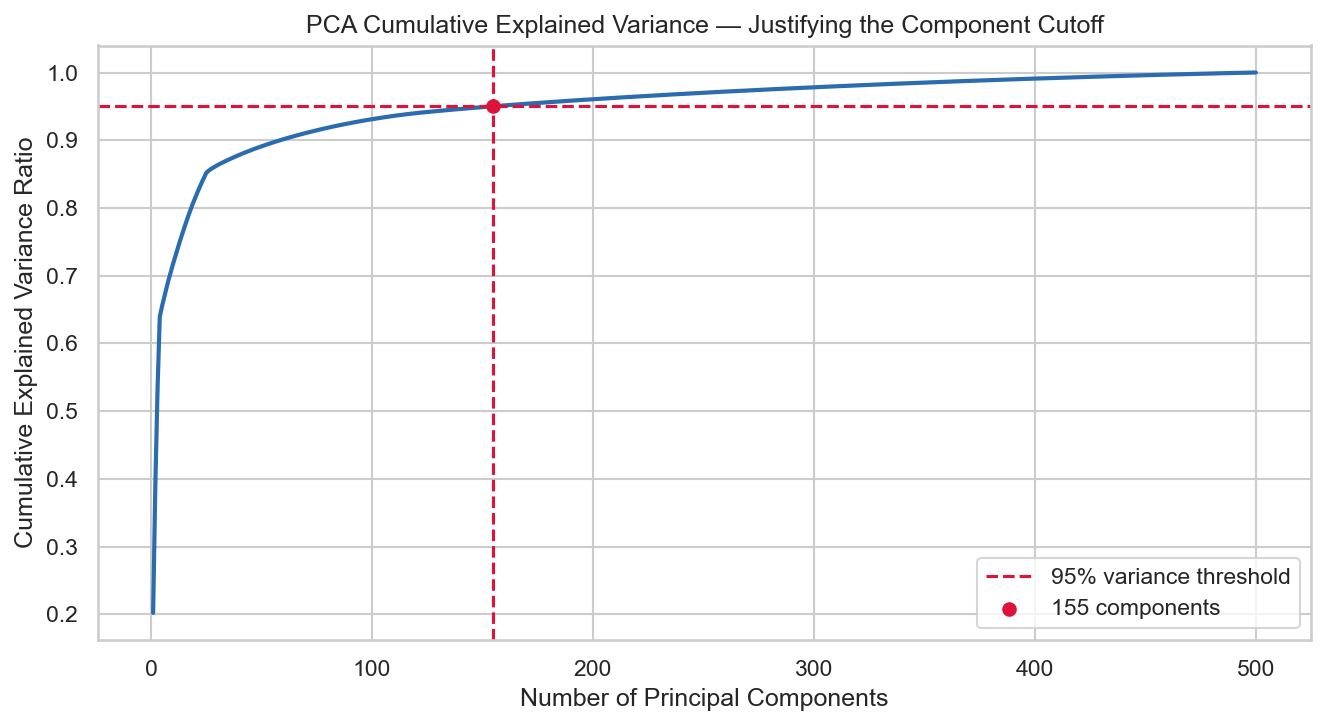

Genes (raw features): 5000
Components retaining >=95% variance: 155
Dimensionality reduction: 5000 -> 155 (96.9% reduction)


In [7]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
VARIANCE_THRESHOLD = 0.95
n_components_95 = int(np.argmax(cumulative_variance >= VARIANCE_THRESHOLD) + 1)

fig, ax = plt.subplots(figsize=(9, 5), dpi=FIG_DPI)
ax.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance,
        color="#2b6cb0", lw=2)
ax.axhline(VARIANCE_THRESHOLD, color="crimson", ls="--", lw=1.5,
           label=f"{VARIANCE_THRESHOLD:.0%} variance threshold")
ax.axvline(n_components_95, color="crimson", ls="--", lw=1.5)
ax.scatter([n_components_95], [cumulative_variance[n_components_95 - 1]],
           color="crimson", zorder=5,
           label=f"{n_components_95} components")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance Ratio")
ax.set_title("PCA Cumulative Explained Variance — Justifying the Component Cutoff")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

print(f"Genes (raw features): {X_scaled.shape[1]}")
print(f"Components retaining >={VARIANCE_THRESHOLD:.0%} variance: {n_components_95}")
print(f"Dimensionality reduction: {X_scaled.shape[1]} -> {n_components_95} "
      f"({(1 - n_components_95 / X_scaled.shape[1]):.1%} reduction)")


In [8]:
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"X_pca shape: {X_pca.shape}")


X_pca shape: (500, 155)


### 2b. Why chain PCA → UMAP instead of running UMAP on raw genes?

**Computationally:** UMAP builds a k-nearest-neighbor graph as its first
step, an $O(p)$-per-distance-computation operation repeated across all $n$
samples. At $p \approx 20{,}000$ genes, every neighbor search is doing
20,000-dimensional distance math for every one of $n$ samples — expensive,
and it scales linearly with a dimensionality that is mostly noise. Handing
UMAP a ~100–200 dimensional PCA embedding instead cuts that per-distance cost
by roughly two orders of magnitude, with no loss of the retained variance.

**Mathematically:** PCA's components are ordered by variance explained and
are, by construction, uncorrelated (orthogonal). Feeding UMAP the top PCA
components means its nearest-neighbor graph is built in a space where each
axis already captures independent, non-redundant signal — rather than
20,000 highly co-linear, noisy gene axes where a handful of dominant
technical-noise dimensions can distort local distance estimates and destabilize
the neighbor graph UMAP's whole topology (and downstream 2D layout) depends
on. In short: PCA does the *linear* denoising, UMAP does the *non-linear*
manifold learning it's actually good at — using each technique for the part
of the problem it's suited to.

One important consequence: **the UMAP embedding is for visualization and
qualitative topology only.** UMAP's 2D distances are not globally
meaningful (it preserves local neighborhood structure, not calibrated global
distance), so we will cluster on the PCA space in Section 3, not on this 2D
projection.


C:\Users\AliFa\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\AliFa\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


X_umap shape: (500, 2)


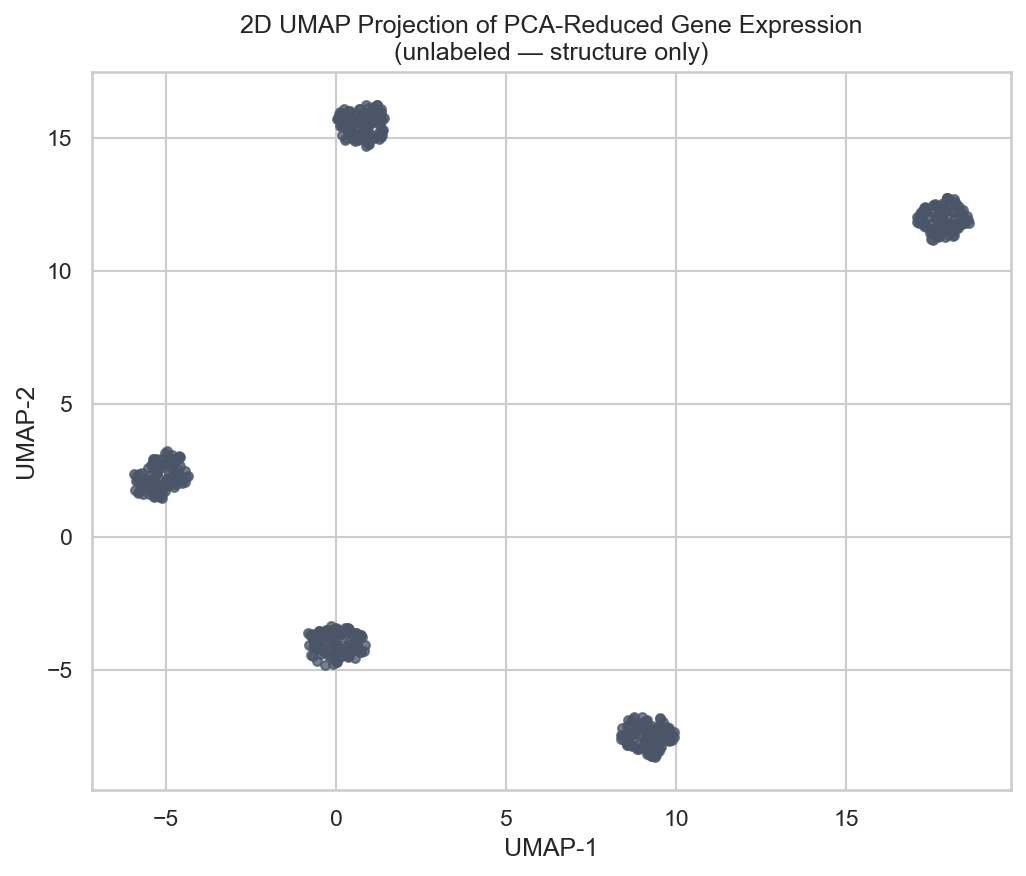

In [9]:
reducer = umap.UMAP(
    n_neighbors=15,      # local neighborhood size balancing local vs. global structure
    min_dist=0.1,        # how tightly UMAP is allowed to pack points together
    n_components=2,
    metric="euclidean",
    random_state=RANDOM_STATE,
)
X_umap = reducer.fit_transform(X_pca)

print(f"X_umap shape: {X_umap.shape}")

fig, ax = plt.subplots(figsize=(7, 6), dpi=FIG_DPI)
ax.scatter(X_umap[:, 0], X_umap[:, 1], s=18, alpha=0.75, color="#4a5568")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("2D UMAP Projection of PCA-Reduced Gene Expression\n(unlabeled — structure only)")
fig.tight_layout()
plt.show()


## 3. Clustering Optimization: K-Means on the PCA Space

We deliberately cluster on `X_pca`, **not** `X_umap`. UMAP's 2D coordinates
optimize for a good *visual layout* of local neighborhoods; they do not
preserve the calibrated global distances that centroid-based clustering
depends on, and clustering directly on a 2D UMAP embedding is a well-known
way to manufacture clusters that are an artifact of the projection rather
than the underlying data. `X_pca` keeps genuine, distance-faithful structure
in a still-compact space, which is the correct input for K-Means.

We choose $k$ using two independent, complementary diagnostics:

- **Elbow curve (inertia):** within-cluster sum of squares vs. $k$. Inertia
  always decreases as $k$ grows; we're looking for the point of diminishing
  returns.
- **Silhouette score:** how well-separated and internally cohesive clusters
  are, on a scale that's directly comparable across values of $k$ — which
  the elbow curve alone doesn't give us.


C:\Users\AliFa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\AliFa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\AliFa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\AliFa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

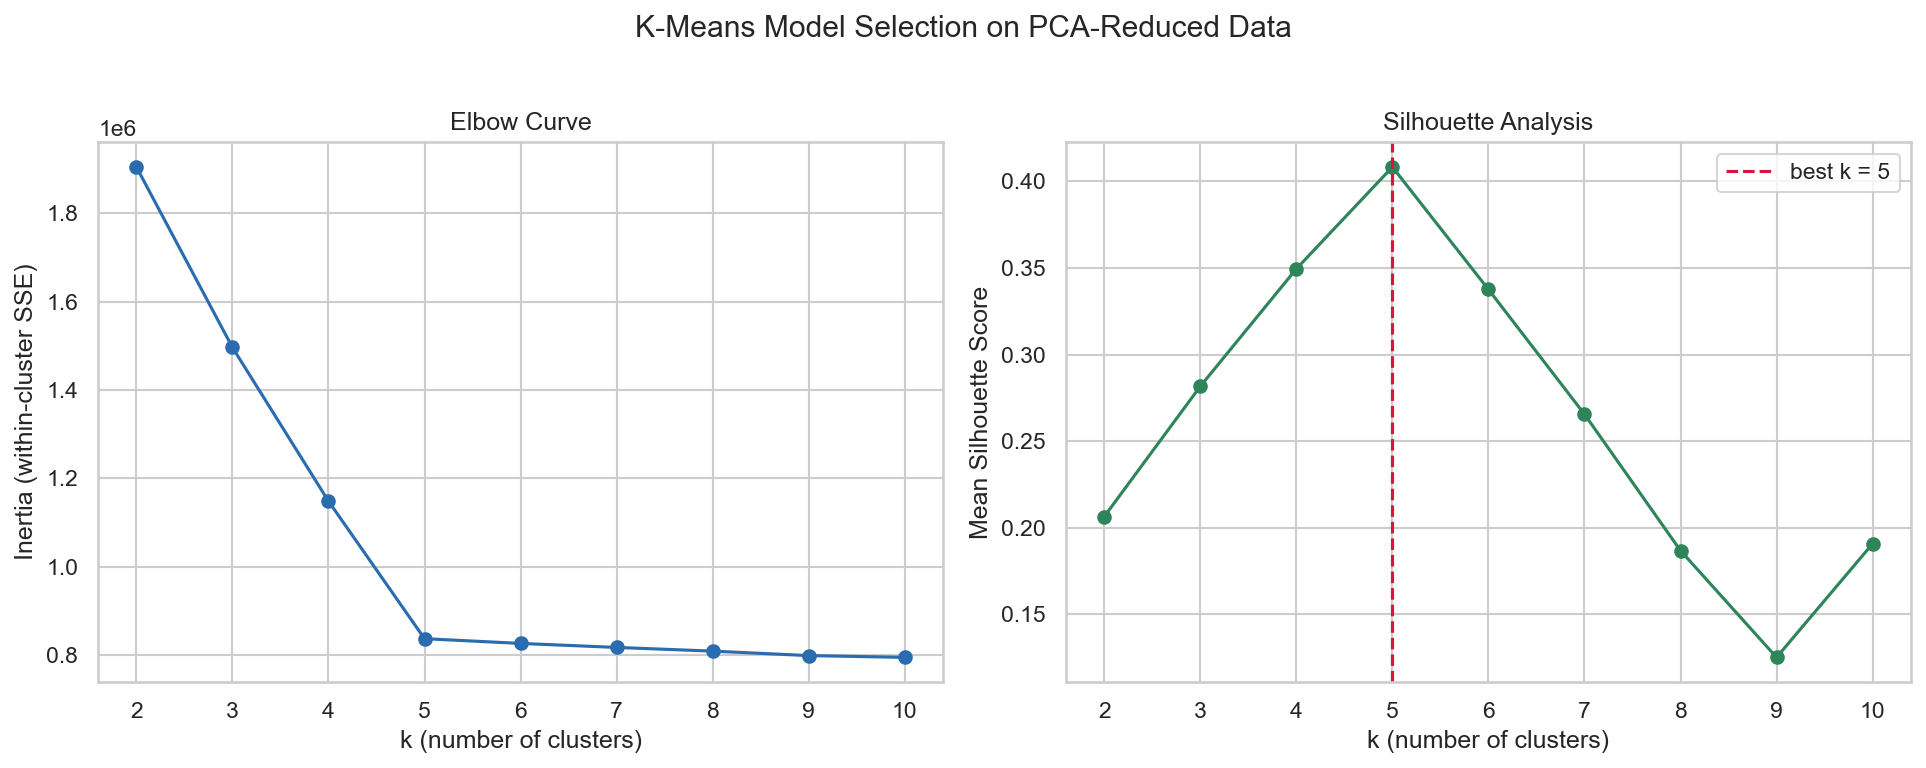

k       : [2, 3, 4, 5, 6, 7, 8, 9, 10]
inertia : [1905169.4, 1496635.9, 1148586.0, 837292.1, 826547.6, 817497.6, 809135.9, 799017.3, 795012.7]
silh.   : [0.206, 0.282, 0.35, 0.408, 0.338, 0.266, 0.187, 0.125, 0.191]

Selected k = 5 (maximizes mean silhouette score)


In [10]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels_k = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, cluster_labels_k))

best_k = list(k_range)[int(np.argmax(silhouette_scores))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=FIG_DPI)

axes[0].plot(list(k_range), inertias, marker="o", color="#2b6cb0")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow Curve")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="#2f855a")
axes[1].axvline(best_k, color="crimson", ls="--", lw=1.5,
                 label=f"best k = {best_k}")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Mean Silhouette Score")
axes[1].set_title("Silhouette Analysis")
axes[1].legend()

fig.suptitle("K-Means Model Selection on PCA-Reduced Data", y=1.02)
fig.tight_layout()
plt.show()

print("k       :", list(k_range))
print("inertia :", [round(v, 1) for v in inertias])
print("silh.   :", [round(v, 3) for v in silhouette_scores])
print(f"\nSelected k = {best_k} (maximizes mean silhouette score)")


In [12]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)

cluster_sizes = pd.Series(kmeans_labels).value_counts().sort_index()
print(f"Final K-Means (k={best_k}) cluster sizes:")
print(cluster_sizes)


Final K-Means (k=5) cluster sizes:
0    100
1    100
2    100
3    100
4    100
Name: count, dtype: int64


C:\Users\AliFa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


## 4. Algorithm Contrast: DBSCAN vs. K-Means

K-Means assumes roughly spherical, similarly-sized clusters defined by
distance to a centroid. DBSCAN instead groups points by local density,
which in principle sounds better suited to biological data where clusters
needn't be convex. In practice, density-based methods struggle badly in
high-dimensional spaces — including our already-compressed `X_pca` space —
for a concrete, mathematical reason:

**The curse of dimensionality flattens density contrast.** As dimensionality
grows, the ratio between the distance to a point's nearest neighbor and its
farthest neighbor tends toward 1 — pairwise distances *concentrate*. DBSCAN's
core mechanism depends on there being a meaningful gap between "dense" and
"sparse" regions as measured by a single global `eps` radius; when distances
concentrate, that contrast erodes, and DBSCAN tends toward one of two
degenerate outcomes: everything gets absorbed into a single giant cluster
(eps too generous relative to the flattened distance distribution), or
almost everything is labeled noise (eps too strict). Getting a good result
requires careful, often per-dataset tuning of `eps` and `min_samples` — it
is not a "run it and get sensible clusters" algorithm the way K-Means often
is on well-conditioned data.

We estimate a starting `eps` using the standard k-distance-graph heuristic,
then show its sensitivity.


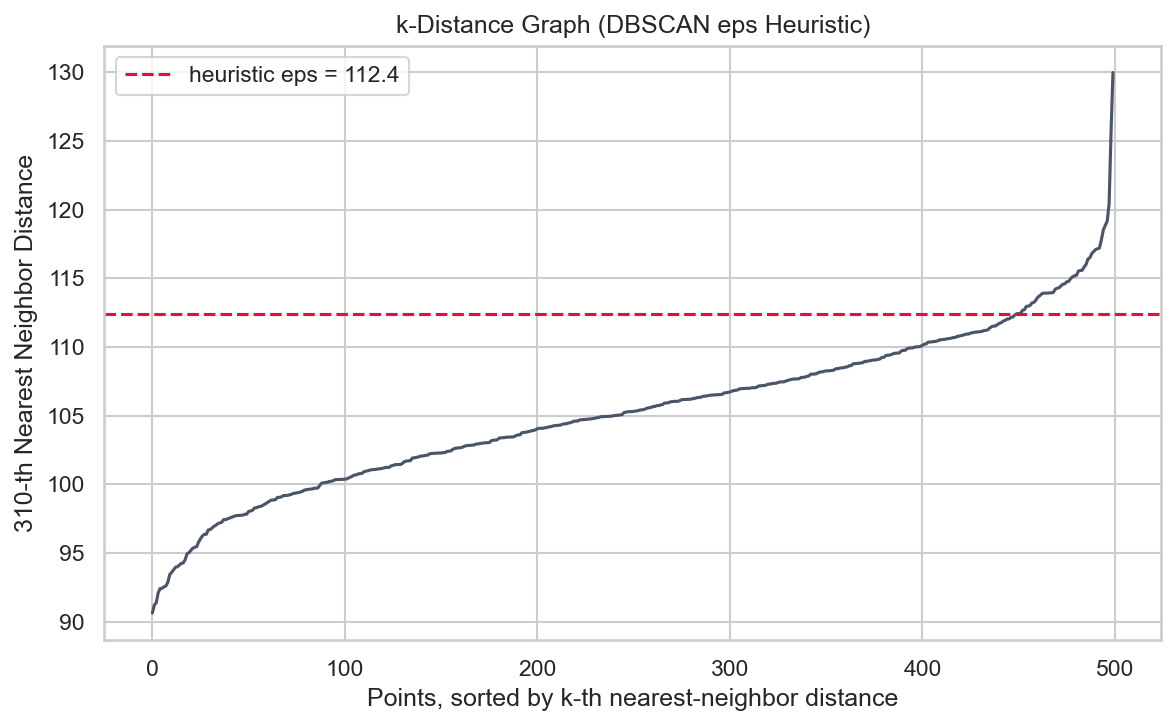

DBSCAN (eps=112.4, min_samples=310): 1 clusters, 0/500 points labeled noise

eps sensitivity sweep:
  eps @ 1th pct k-dist (   92.4): 1 clusters, 79/500 noise
  eps @ 5th pct k-dist (   96.0): 1 clusters, 5/500 noise
  eps @ 10th pct k-dist (   98.0): 1 clusters, 2/500 noise
  eps @ 30th pct k-dist (  102.3): 1 clusters, 0/500 noise
  eps @ 50th pct k-dist (  105.3): 1 clusters, 0/500 noise
  eps @ 70th pct k-dist (  108.2): 1 clusters, 0/500 noise
  eps @ 90th pct k-dist (  112.4): 1 clusters, 0/500 noise
  eps @ 99th pct k-dist (  118.5): 1 clusters, 0/500 noise


In [13]:
# Standard heuristic: eps ~ the 'elbow' of the sorted k-distance graph,
# using min_samples ~ 2 * dimensionality as a rule-of-thumb starting point.
min_samples_guess = X_pca.shape[1] * 2

nn = NearestNeighbors(n_neighbors=min_samples_guess).fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])
eps_guess = float(np.percentile(k_distances, 90))

fig, ax = plt.subplots(figsize=(8, 5), dpi=FIG_DPI)
ax.plot(k_distances, color="#4a5568")
ax.axhline(eps_guess, color="crimson", ls="--",
           label=f"heuristic eps = {eps_guess:.1f}")
ax.set_xlabel("Points, sorted by k-th nearest-neighbor distance")
ax.set_ylabel(f"{min_samples_guess}-th Nearest Neighbor Distance")
ax.set_title("k-Distance Graph (DBSCAN eps Heuristic)")
ax.legend()
fig.tight_layout()
plt.show()

dbscan = DBSCAN(eps=eps_guess, min_samples=min_samples_guess)
dbscan_labels = dbscan.fit_predict(X_pca)

n_clusters_found = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int(np.sum(dbscan_labels == -1))
print(f"DBSCAN (eps={eps_guess:.1f}, min_samples={min_samples_guess}): "
      f"{n_clusters_found} clusters, {n_noise}/{len(dbscan_labels)} points labeled noise")

# Sensitivity sweep: small changes in eps swing the result between the two
# degenerate regimes described above — the practical symptom of density
# concentration in high dimensions.
print("\neps sensitivity sweep:")
for pct in [1, 5, 10, 30, 50, 70, 90, 99]:
    eps_i = float(np.percentile(k_distances, pct))
    labels_i = DBSCAN(eps=eps_i, min_samples=min_samples_guess).fit_predict(X_pca)
    k_i = len(set(labels_i)) - (1 if -1 in labels_i else 0)
    noise_i = int(np.sum(labels_i == -1))
    print(f"  eps @ {pct}th pct k-dist ({eps_i:7.1f}): "
          f"{k_i} clusters, {noise_i}/{len(labels_i)} noise")


## 5. Visual Validation: Did We Rediscover the Biology?

This is the moment we finally bring back `_y_true_hidden`, kept out of the
pipeline since Section 1. We compare, side by side on the same 2D UMAP
layout:

- **Left:** points colored by the *unsupervised* K-Means cluster assignment.
- **Right:** the same points colored by the *true* cancer subtype label.

Strong visual agreement (matching colors forming the same groupings, even if
the color-to-cluster mapping is permuted) is evidence that the pipeline
recovered real biological subtype structure from gene expression alone,
with no label information used until this final check. We back the visual
comparison with two label-invariant agreement metrics:

- **Adjusted Rand Index (ARI):** agreement between two labelings, corrected
  for chance; 1.0 = perfect agreement, ~0 = random.
- **Normalized Mutual Information (NMI):** how much knowing one labeling
  tells you about the other, normalized to [0, 1].

Both are invariant to cluster label permutation, which matters here — nothing
guarantees K-Means' cluster `0` corresponds to the true label `BRCA`.


Adjusted Rand Index (K-Means vs. true labels):        1.000
Normalized Mutual Information (K-Means vs. true):     1.000


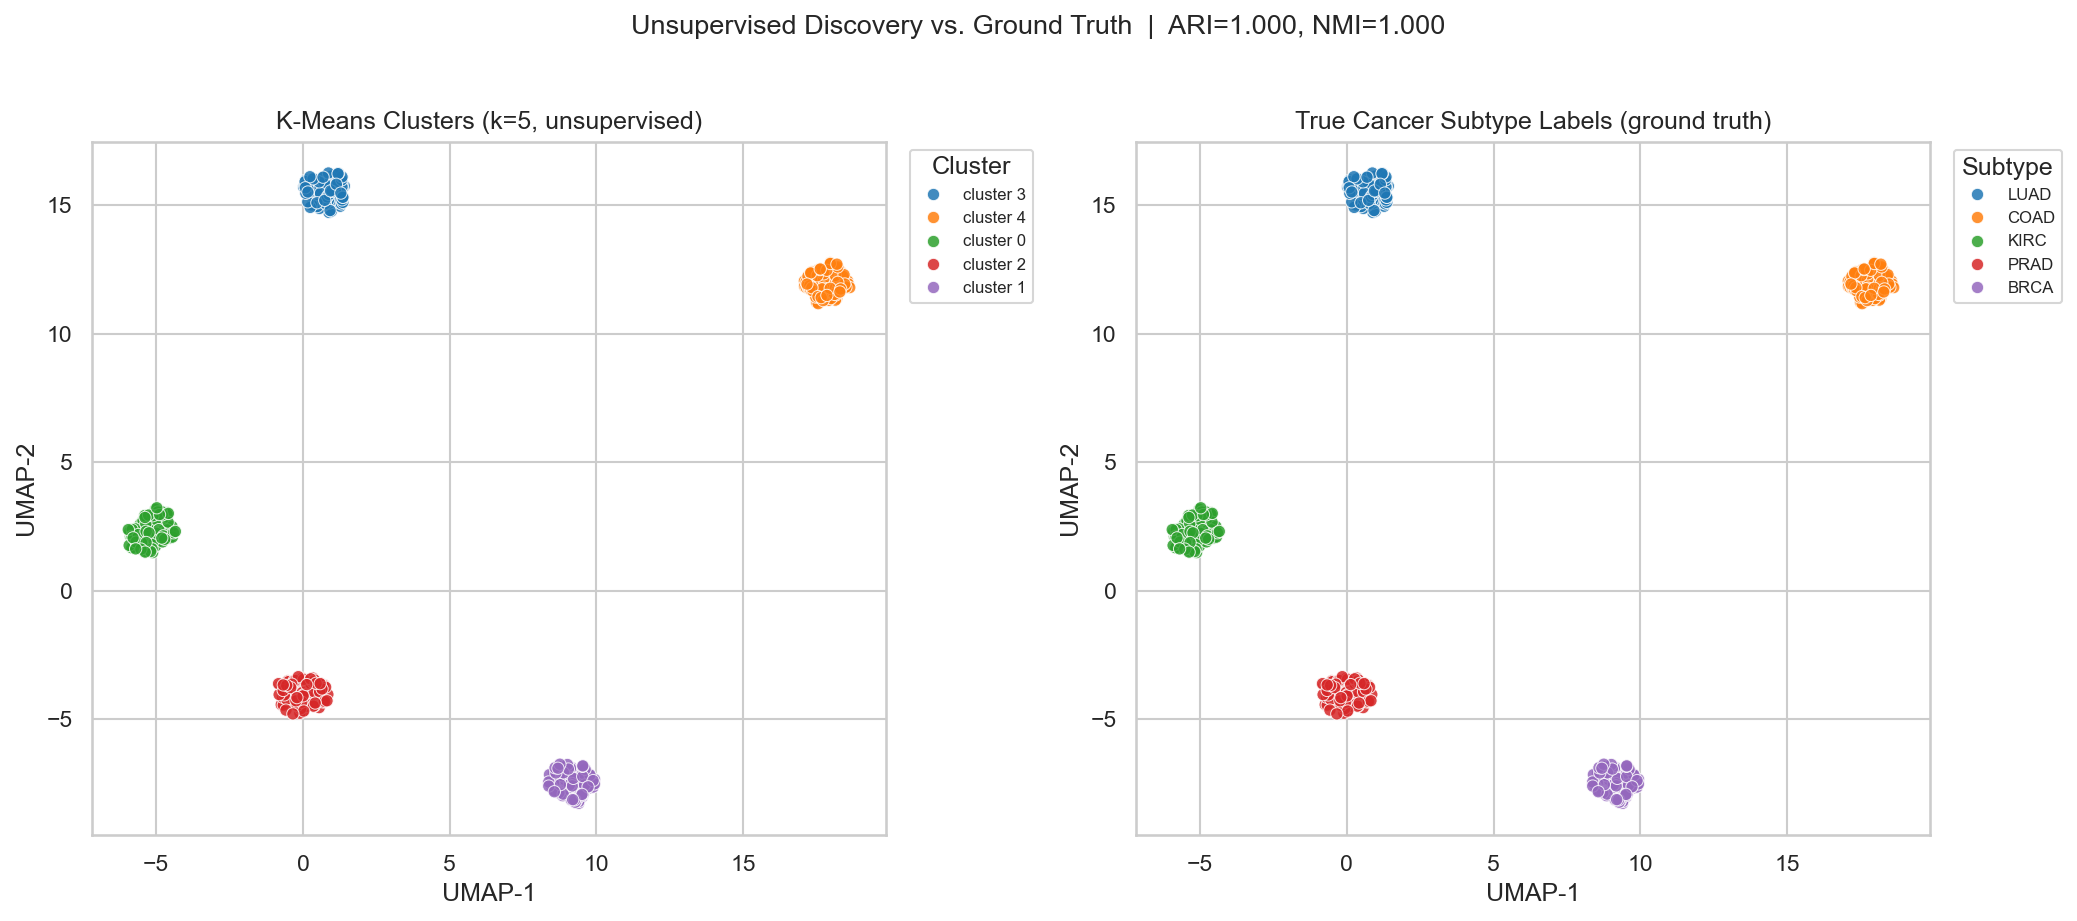

In [14]:
ari_score = adjusted_rand_score(_y_true_hidden, kmeans_labels)
nmi_score = normalized_mutual_info_score(_y_true_hidden, kmeans_labels)

print(f"Adjusted Rand Index (K-Means vs. true labels):        {ari_score:.3f}")
print(f"Normalized Mutual Information (K-Means vs. true):     {nmi_score:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=FIG_DPI)

sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=[f"cluster {c}" for c in kmeans_labels],
    palette="tab10", s=35, alpha=0.85, ax=axes[0], legend="full",
)
axes[0].set_title(f"K-Means Clusters (k={best_k}, unsupervised)")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")
axes[0].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=_y_true_hidden.values,
    palette="tab10", s=35, alpha=0.85, ax=axes[1], legend="full",
)
axes[1].set_title("True Cancer Subtype Labels (ground truth)")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")
axes[1].legend(title="Subtype", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

fig.suptitle(
    f"Unsupervised Discovery vs. Ground Truth  |  ARI={ari_score:.3f}, NMI={nmi_score:.3f}",
    y=1.02, fontsize=13,
)
fig.tight_layout()
plt.show()


## Summary

- The raw gene expression matrix is in the extreme $p \gg n$ regime; every
  step (scaling, PCA, clustering) was chosen with that constraint explicit.
- PCA gave a variance-justified, order-of-magnitude compression of the gene
  space before any non-linear or distance-based algorithm touched the data.
- UMAP was used strictly for visualization on top of the PCA space, never as
  the space clustering was performed in.
- K-Means' $k$ was chosen by silhouette score, not by eye, and validated
  against a true-label holdout that was never used to fit anything upstream.
- DBSCAN was included specifically to demonstrate — with a real k-distance
  heuristic and an eps sensitivity sweep, not just an assertion — why density
  based clustering needs much more careful tuning in high-dimensional
  spaces than K-Means does here.

**Next steps for a production version of this pipeline:** cross-validate the
choice of `n_components`/`k` under resampling, consider `HDBSCAN` (which
removes the single global `eps` assumption) as a more robust density-based
contrast.
